# TC1 - Introdução ao Reconhecimento de Padrões (TI0097)

Nome: Nataniel Marques Viana Neto
Mátricula: 554664

Trabalho computacional sobre a base Wall Following Robot Navigation Data. Na Questão 1 é feita uma análise descritiva usando o arquivo com 4 atributos (sensor_readings_4.data) e na Questão 2 os classificadores são avaliados no problema reduzido a 3 classes, removendo a classe minoritária Slight-Left-Turn.

## Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import time
from pathlib import Path
import urllib.request

sns.set_style("whitegrid")
np.random.seed(42)

## Dados

In [5]:
BASE = "https://github.com/NatanielMarques14/trabalhos-computacionais-reconhecimento-padroes/releases/download/v1.0"

arquivos = [
    "sensor_readings_4.data",
    "sensor_readings_2.data",
    "sensor_readings_24.data",
    "Wall-following.names"
]

for arq in arquivos:
    if not Path(arq).exists():
        urllib.request.urlretrieve(f"{BASE}/{arq}", arq)

## Questão 1 - Análise estatística dos dados

Carregando o arquivo com os 4 atributos simplificados (distância frontal, esquerda, direita e traseira).

In [ ]:
colunas = ["SD_front", "SD_left", "SD_right", "SD_back", "Classe"]
df = pd.read_csv("sensor_readings_4.data", header=None, names=colunas)
atributos = colunas[:-1] # pegamos todos os elementos da lista, exceto o último (classe)
df.head()

,SD_front,SD_left,SD_right,SD_back,Classe
0,1.687,0.445,2.332,0.429,Slight-Right-Turn
1,1.687,0.449,2.332,0.429,Slight-Right-Turn
2,1.687,0.449,2.334,0.429,Slight-Right-Turn
3,1.687,0.449,2.334,0.429,Slight-Right-Turn
4,1.687,0.449,2.334,0.429,Slight-Right-Turn
5,1.686,0.446,2.334,0.430,Slight-Right-Turn
6,1.684,0.451,2.330,0.432,Slight-Right-Turn
7,1.680,0.453,2.327,0.436,Slight-Right-Turn
8,0.753,0.457,2.323,0.442,Sharp-Right-Turn
9,0.744,0.462,2.321,0.449,Sharp-Right-Turn


### (i) Número de classes e instâncias por classe


In [7]:
contagem = df["Classe"].value_counts()
print("Número de classes:", df["Classe"].nunique())
contagem

Número de classes: 4


Classe
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64

A base tem 4 classes, cada uma correspondendo a um comando de movimento do robô. São elas: Move-Forward, Sharp-Right-Turn, Slight-Right-Turn e Slight-Left-Turn. As classes têm respectivamente: 2205, 2097, 826 e 328 instâncias. Ou seja, temos 5456 instâncias no total.

### (ii) Média, variância, assimetria e curtose por classe

Fazendo os cálculos separados por classe para cada um dos 4 atributos.

In [9]:
estatisticas = df.groupby("Classe")[atributos].agg(["mean", "var", "skew"]) # atributos é a lista de colunas que pegamos que não inclui a coluna de classe
# as funções do agrupamento trabalham com cada coluna separadamente, então o resultado de cada métrica é calculado dentro os elementos de cada coluna, e não entre colunas diferentes

def curtose(x):
    return stats.kurtosis(x)

curtoses = df.groupby("Classe")[atributos].agg(curtose)
curtoses.columns = pd.MultiIndex.from_product([atributos, ["kurtosis"]]) # estatisticas de curtose não são calculadas pelo método agg, então precisamos criar um multiindex para a coluna de curtose

pd.concat([estatisticas, curtoses], axis=1).sort_index(axis=1)

SD_back                                SD_front  \
                    kurtosis      mean      skew       var  kurtosis   
Classe                                                                 
Move-Forward       17.135170  1.080591  3.318200  0.341457  1.943839   
Sharp-Right-Turn    3.247686  1.434310  1.933195  1.121251  4.080101   
Slight-Left-Turn   10.299400  2.153622  1.876293  0.206765 -1.284144   
Slight-Right-Turn  -0.175661  1.031969 -0.299419  0.090603  8.103239   

                                                   SD_left            \
                       mean      skew       var   kurtosis      mean   
Classe                                                                 
Move-Forward       1.584937  1.467565  0.467914  -0.942694  0.652264   
Sharp-Right-Turn   0.799622 -1.827464  0.005397  78.967451  0.663477   
Slight-Left-Turn   1.456259  0.056162  0.105220   4.923948  1.563058   
Slight-Right-Turn  1.683617  2.172875  0.281631   1.233756  0.453715   

                                       SD_right                                
                       skew       var  kurtosis      mean      skew       var  
Classe                                                                         
Move-Forward       0.168904  0.008977  0.693613  1.863251  1.163584  0.283098  
Sharp-Right-Turn   7.770467  0.109105 -0.520000  1.912139  0.669554  0.448719  
Slight-Left-Turn   1.578531  0.275643  0.293983  1.632399  0.513797  0.098313  
Slight-Right-Turn -1.484722  0.001609  7.753439  1.953452  1.996049  0.123944

### (iii) Histogramas dos atributos

Um histograma por atributo, separando as classes por cor para ver como a densidade de cada uma se distribui.

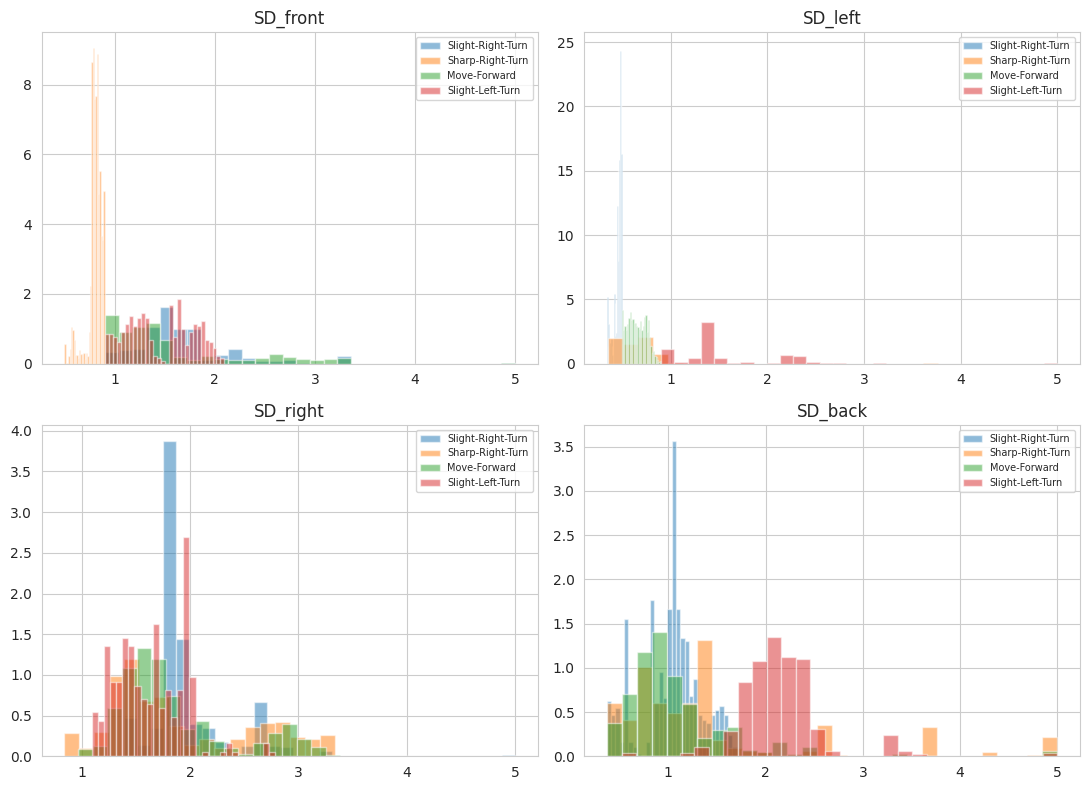

In [10]:
fig, eixos = plt.subplots(2, 2, figsize=(11, 8))
for eixo, atributo in zip(eixos.ravel(), atributos):
    for classe in df["Classe"].unique():
        dados = df.loc[df["Classe"] == classe, atributo]
        eixo.hist(dados, bins=30, alpha=0.5, label=classe, density=True)
    eixo.set_title(atributo)
    eixo.legend(fontsize=7)
plt.tight_layout()
plt.show()

Os histogramas mostram a distribuição dos valores dos quatro sensores (atributos) (`SD_front`, `SD_left`, `SD_right` e `SD_back`) para cada uma das quatro classes de movimento do robô. Como foi utilizada a opção `density=True`, a altura das barras representa uma estimativa da densidade de probabilidade, permitindo comparar o formato das distribuições entre as diferentes classes independentemente da quantidade de instâncias, ou seja, quanto maior a barra, mais comum é achar aquele valor daquele intervalo. O eixo X mostra os valores que aquele determinado sensor mediu, como por exemplo, o gráfico do SD_right temos valores como 1.0, 1.5, 2.0, 2.5 e 3.0.


De modo geral, observa-se que existe uma considerável sobreposição entre as distribuições das classes, indicando que um único atributo, isoladamente, não é suficiente para separar perfeitamente todos os movimentos.

No atributo **SD_front**, a classe **Sharp-Right-Turn** concentra a maior parte das observações em valores mais baixos (próximos de 0,8), enquanto as demais classes apresentam distribuições mais espalhadas e parcialmente sobrepostas. A classe **Move-Forward** é a que apresenta maior dispersão, alcançando valores superiores a 3,0.

O atributo **SD_left** é o que demonstra a separação visual mais evidente entre algumas classes. A classe **Slight-Right-Turn** concentra-se fortemente em valores baixos, enquanto **Slight-Left-Turn** apresenta valores predominantemente mais altos, sugerindo que esse sensor possui boa capacidade discriminativa para esses movimentos.

No caso de **SD_right**, todas as classes apresentam distribuições bastante concentradas entre aproximadamente 1,5 e 2,5, com forte sobreposição. Embora existam pequenas diferenças na forma das distribuições e na dispersão, esse atributo, isoladamente, oferece menor poder de distinção entre as classes.

Por fim, o atributo **SD_back** também apresenta sobreposição entre as distribuições, porém nota-se que a classe **Slight-Left-Turn** tende a assumir valores mais elevados que as demais, enquanto **Slight-Right-Turn** concentra-se em valores menores. Além disso, observa-se a presença de alguns valores extremos, principalmente na classe **Sharp-Right-Turn**, indicando a existência de poucas observações distantes da maior parte dos dados.

De forma geral, a análise visual indica que nenhum dos sensores é suficiente, sozinho, para classificar perfeitamente os movimentos do robô. Entretanto, alguns atributos, especialmente **SD_left** e **SD_back**, apresentam padrões que podem contribuir significativamente para a diferenciação entre as classes quando utilizados em conjunto em um modelo de classificação.

### (iv) Scatterplot map dos pares de atributos

Colocando todas as combinações de pares para enxergar visualmente se existe alguma relação entre os atributos.

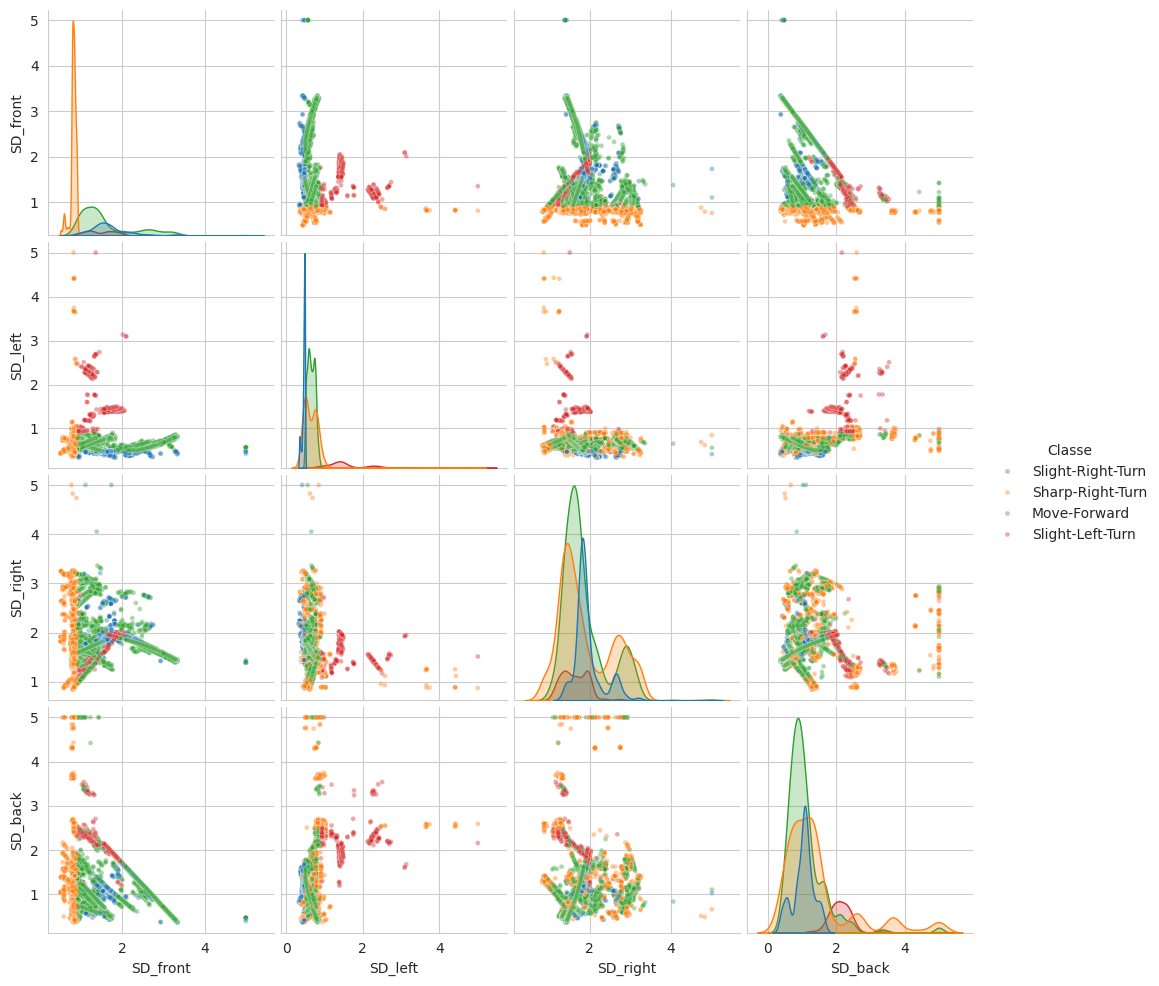

In [11]:
sns.pairplot(df, hue="Classe", vars=atributos, plot_kws={"alpha": 0.4, "s": 12})
plt.show()

O gráfico de pares (*pairplot*) permite analisar simultaneamente a distribuição individual de cada atributo e o relacionamento entre todos os pares de atributos, considerando as quatro classes de movimento do robô. Na diagonal principal são apresentadas as distribuições de densidade de cada atributo, enquanto as demais posições mostram gráficos de dispersão entre dois atributos distintos, possibilitando identificar padrões, correlações e possíveis regiões de separação entre as classes.

De maneira geral, observa-se que existe uma considerável sobreposição entre as classes, indicando que a tarefa de classificação não é trivial e que dificilmente um único atributo é suficiente para distinguir perfeitamente todos os movimentos do robô. Ainda assim, algumas combinações de atributos apresentam agrupamentos mais definidos, sugerindo que a utilização conjunta das informações pode aumentar o poder de discriminação dos modelos de classificação.

As distribuições na diagonal mostram que os atributos **SD_right** e **SD_back** apresentam maior dispersão dos valores, enquanto **SD_left** e **SD_front** possui valores mais concentrados em faixas menores. O atributo **SD_right** concentra grande parte das observações entre aproximadamente 1,5 e 2,5, embora ainda apresente sobreposição entre as classes.

Nos gráficos de dispersão também é possível observar relações entre alguns atributos. Em combinações envolvendo **SD_front** e **SD_back**, nota-se uma tendência de relação inversa em parte das observações, enquanto outras combinações apresentam nuvens de pontos mais espalhadas, sem uma relação linear evidente. Além disso, algumas classes ocupam regiões específicas do espaço de atributos, porém essas regiões frequentemente se sobrepõem às das demais classes.

De forma geral, o *pairplot* reforça que os atributos possuem comportamento distinto entre as classes, mas também evidencia uma significativa interseção entre elas. Essa análise está de acordo com a natureza do conjunto de dados, no qual a tarefa de navegação do robô não é linearmente separável, indicando que modelos capazes de explorar relações conjuntas entre os atributos tendem a apresentar melhor desempenho do que abordagens baseadas em um único atributo ou em separações lineares simples.

### (v) Matriz de correlação

Calculando a correlação de Pearson entre os 4 atributos e comparando com o que foi visto no scatterplot.

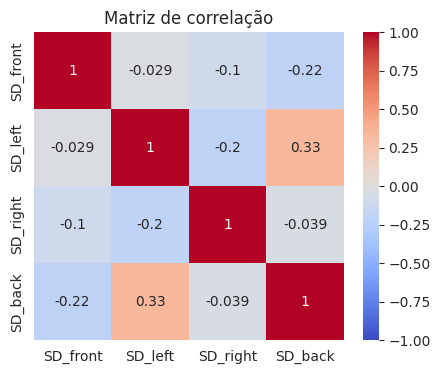

,SD_front,SD_left,SD_right,SD_back
SD_front,1.000000,-0.028617,-0.102938,-0.217564
SD_left,-0.028617,1.000000,-0.203957,0.331701
SD_right,-0.102938,-0.203957,1.000000,-0.039305
SD_back,-0.217564,0.331701,-0.039305,1.000000


In [12]:
matriz_corr = df[atributos].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.show()
matriz_corr

A matriz confirma o que o scatterplot já sugeria, os valores de correlação são baixos ou moderados, sem nenhum par fortemente correlacionado. As maiores e menores (mais negativas) correlações ocorrem com o SD_back, sendo o SD_back com o SD_front a correlação mais negativa(-0.22) e o SD_back com SD_left a maior correlação(0.33), o restante das correlações do SD_front são perto de zero. Os dois métodos são complementares e não equivalentes, a matriz dá o número exato de forma rápida mas o scatterplot mostra o formato da relação, por exemplo se ela é linear, se existe alguma curva ou se são pontos espalhados sem padrão algum, coisa que só o coeficiente de correlação sozinho não conta.

## Questão 2 - Classificação de padrões

O problema original tem 4 classes. Aqui a classe Slight-Left-Turn é removida por ser a minoritária e muito menos representada que as outras (menos de 6% das amostras), ficando o problema com as 3 classes restantes: Move-Forward, Slight-Right-Turn e Sharp-Right-Turn.

In [ ]:
df3 = df[df["Classe"] != "Slight-Left-Turn"].reset_index(drop=True)
X = df3[atributos].values
y = df3["Classe"].values
classes = sorted(df3["Classe"].unique())
df3["Classe"].value_counts()

### Implementação dos classificadores

Cada função de treino devolve o que o classificador precisa guardar junto com o tempo gasto, e cada função de previsão devolve os rótulos preditos junto com o tempo de teste.

In [ ]:
def treinar_nn(X_train, y_train):
    t0 = time.perf_counter()
    tempo = time.perf_counter() - t0
    return (X_train, y_train), tempo

def prever_nn(modelo, X_test, p):
    X_train, y_train = modelo
    t0 = time.perf_counter()
    distancias = cdist(X_test, X_train, metric="minkowski", p=p)
    y_pred = y_train[np.argmin(distancias, axis=1)]
    tempo = time.perf_counter() - t0
    return y_pred, tempo

In [ ]:
def treinar_centroide(X_train, y_train, robusto=False):
    t0 = time.perf_counter()
    protos = {}
    for c in classes:
        Xc = X_train[y_train == c]
        protos[c] = np.median(Xc, axis=0) if robusto else np.mean(Xc, axis=0)
    tempo = time.perf_counter() - t0
    return protos, tempo

def prever_centroide(protos, X_test):
    t0 = time.perf_counter()
    nomes = list(protos.keys())
    M = np.array([protos[c] for c in nomes])
    distancias = cdist(X_test, M)
    y_pred = np.array(nomes)[np.argmin(distancias, axis=1)]
    tempo = time.perf_counter() - t0
    return y_pred, tempo

In [ ]:
def treinar_correlacao(X_train, y_train):
    t0 = time.perf_counter()
    protos = {c: X_train[y_train == c].mean(axis=0) for c in classes}
    tempo = time.perf_counter() - t0
    return protos, tempo

def prever_correlacao(protos, X_test):
    t0 = time.perf_counter()
    nomes = list(protos.keys())
    M = np.array([protos[c] for c in nomes])
    Mc = M - M.mean(axis=1, keepdims=True)
    Xc = X_test - X_test.mean(axis=1, keepdims=True)
    numerador = Xc @ Mc.T
    denominador = np.linalg.norm(Xc, axis=1)[:, None] * np.linalg.norm(Mc, axis=1)[None, :]
    denominador[denominador == 0] = 1e-12
    correlacoes = numerador / denominador
    y_pred = np.array(nomes)[np.argmax(correlacoes, axis=1)]
    tempo = time.perf_counter() - t0
    return y_pred, tempo

### Protocolo experimental

Rodando 100 repetições de treino-teste para cada uma das 5 proporções pedidas (20/80, 30/70, 50/50, 70/30 e 80/20), guardando a acurácia, os tempos e, para cada combinação de classificador com proporção, a rodada de melhor e de pior acurácia para depois montar as matrizes de confusão.

In [ ]:
ordens_minkowski = {"p=0,5": 0.5, "p=2/3": 2/3, "p=1": 1.0, "p=3/2": 1.5, "p=2": 2.0, "p=5/2": 2.5}
proporcoes_treino = [0.2, 0.3, 0.5, 0.7, 0.8]
n_rodadas = 100

linhas_resultado = []
linhas_por_classe = []
extremos = {}

for proporcao in proporcoes_treino:
    for rodada in range(n_rodadas):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=proporcao, stratify=y, random_state=rodada
        )

        previsoes_da_rodada = {}

        modelo_nn, t_treino_nn = treinar_nn(X_train, y_train)
        for nome_p, p in ordens_minkowski.items():
            y_pred, t_teste = prever_nn(modelo_nn, X_test, p)
            previsoes_da_rodada[f"NN Minkowski ({nome_p})"] = (y_pred, t_treino_nn, t_teste)

        protos_c, t_treino_c = treinar_centroide(X_train, y_train, robusto=False)
        y_pred, t_teste = prever_centroide(protos_c, X_test)
        previsoes_da_rodada["Distância mínima ao centroide"] = (y_pred, t_treino_c, t_teste)

        protos_r, t_treino_r = treinar_centroide(X_train, y_train, robusto=True)
        y_pred, t_teste = prever_centroide(protos_r, X_test)
        previsoes_da_rodada["Centroide robusto (mediana)"] = (y_pred, t_treino_r, t_teste)

        protos_corr, t_treino_corr = treinar_correlacao(X_train, y_train)
        y_pred, t_teste = prever_correlacao(protos_corr, X_test)
        previsoes_da_rodada["Máxima correlação"] = (y_pred, t_treino_corr, t_teste)

        for nome_modelo, (y_pred, t_treino, t_teste) in previsoes_da_rodada.items():
            acuracia = (y_pred == y_test).mean()
            linhas_resultado.append({
                "modelo": nome_modelo,
                "proporcao_treino": proporcao,
                "rodada": rodada,
                "acuracia": acuracia,
                "tempo_treino": t_treino,
                "tempo_teste": t_teste,
            })

            for classe in classes:
                mascara = y_test == classe
                if mascara.sum() > 0:
                    acc_classe = (y_pred[mascara] == y_test[mascara]).mean()
                    linhas_por_classe.append({
                        "modelo": nome_modelo,
                        "proporcao_treino": proporcao,
                        "rodada": rodada,
                        "classe": classe,
                        "acuracia": acc_classe,
                    })

            chave = (nome_modelo, proporcao)
            if chave not in extremos or acuracia > extremos[chave]["melhor_acc"]:
                if chave not in extremos:
                    extremos[chave] = {}
                extremos[chave]["melhor_acc"] = acuracia
                extremos[chave]["melhor_cm"] = confusion_matrix(y_test, y_pred, labels=classes)
            if "pior_acc" not in extremos[chave] or acuracia < extremos[chave]["pior_acc"]:
                extremos[chave]["pior_acc"] = acuracia
                extremos[chave]["pior_cm"] = confusion_matrix(y_test, y_pred, labels=classes)

resultados = pd.DataFrame(linhas_resultado)
resultados_por_classe = pd.DataFrame(linhas_por_classe)
print("Total de execuções:", len(resultados))

### OBS 2 e OBS 3 - Estatísticas de desempenho por modelo e por proporção de treino

Juntando as 100 rodadas de cada proporção e tirando média, desvio padrão, máximo, mínimo e mediana da acurácia.

In [ ]:
resumo = resultados.groupby(["modelo", "proporcao_treino"])["acuracia"].agg(
    ["mean", "std", "max", "min", "median"]
).round(4)
resumo

Dá pra ver o efeito da proporção treino teste olhando essa tabela, em geral a acurácia melhora conforme a fração de treino aumenta, já que os classificadores têm mais exemplos pra construir seus centroides ou vizinhos, mas o ganho começa a ficar pequeno depois de 50/50 ou 70/30, mostrando que a base já tem informação suficiente sem precisar de proporções extremas de treino.

### OBS 1 - Tempos de treinamento e teste

Média dos tempos de treino e teste por modelo, juntando todas as proporções e rodadas.

In [ ]:
tempos = resultados.groupby("modelo")[["tempo_treino", "tempo_teste"]].mean().round(6)
tempos.sort_values("tempo_teste")

Os classificadores de centroide e de máxima correlação são bem mais rápidos no teste porque comparam cada amostra com só 3 protótipos, um por classe. Já o classificador do vizinho mais próximo precisa calcular a distância até todos os exemplos de treino guardados, então o tempo de teste cresce com o tamanho do conjunto de treino, ficando mais lento nas proporções de treino maiores.

### Matriz de confusão da melhor e da pior rodada

Escolhendo o modelo com a maior acurácia média (olhando o resumo acima) e mostrando a matriz de confusão da rodada em que ele mais acertou e da rodada em que ele menos acertou, na proporção 70/30.

In [ ]:
melhor_modelo = resumo.xs(0.7, level="proporcao_treino")["mean"].idxmax()
print("Melhor modelo na proporção 70/30:", melhor_modelo)

chave = (melhor_modelo, 0.7)
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(extremos[chave]["melhor_cm"], annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes, ax=eixos[0])
eixos[0].set_title(f"Melhor rodada (acc={extremos[chave]['melhor_acc']:.3f})")
sns.heatmap(extremos[chave]["pior_cm"], annot=True, fmt="d", cmap="Reds",
            xticklabels=classes, yticklabels=classes, ax=eixos[1])
eixos[1].set_title(f"Pior rodada (acc={extremos[chave]['pior_acc']:.3f})")
for eixo in eixos:
    eixo.set_xlabel("Predito")
    eixo.set_ylabel("Real")
plt.tight_layout()
plt.show()

### OBS 4 - Desempenho por classe

Vendo se alguma classe é sistematicamente mais fácil ou mais difícil de acertar que as outras, usando a proporção 70/30 como referência.

In [ ]:
resumo_por_classe = resultados_por_classe[resultados_por_classe["proporcao_treino"] == 0.7].groupby(
    ["modelo", "classe"]
)["acuracia"].agg(["mean", "std"]).round(4)
resumo_por_classe

Olhando essa tabela, Move-Forward costuma ter a maior acurácia entre as três classes na maioria dos modelos, provavelmente porque tem mais amostras e um padrão de sensores mais distinto (distâncias grandes em várias direções). Slight-Right-Turn tende a ser a mais confundida, principalmente com Sharp-Right-Turn, o que faz sentido porque as duas representam o mesmo tipo de manobra em graus diferentes de intensidade, então os valores dos sensores ficam parecidos entre elas.